# 🇪🇬 Egypt Food Prices — Exploratory Data Analysis (EDA)
**Source:** WFP Food Prices Database

---
### Unit Rules
| Group | Products | Unit | Analysed As |
|-------|----------|------|-------------|
| KG | Rice, Wheat, Chicken, Milk, Sugar, Oil, Lentils, Beans, Tomatoes, Cucumbers, Pasta | KG | EGP / KG |
| Per-piece | Eggs | 1 piece | EGP / piece |
| Per-pack | Cheese (Nesto) | 8 pcs | EGP / pack |

> Each group is **always** analysed and plotted separately. Prices from different unit groups are never compared on the same chart.

## 0. Setup

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250', 'axes.labelcolor': '#c8cfe8',
    'axes.titlecolor': '#ffffff', 'xtick.color': '#8890b0',
    'ytick.color': '#8890b0', 'text.color': '#c8cfe8',
    'grid.color': '#2e3250', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})
P  = ['#4f8ef7','#f7a24f','#4ff7a2','#f74f8e','#a24ff7','#f7f74f','#4ff7f7']
BG = '#0f1117'

FIG_DIR = '../../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight', facecolor=BG)

MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('Setup done')

Setup done


## 1. Load & Inspect

In [94]:
df = pd.read_csv('../../Data/preprocessed/preprocessed data.csv')
df.columns = df.columns.str.strip()

df['Date']       = pd.to_datetime(df['Date'], format='%b-%Y')
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

print(f'Shape        : {df.shape}')
print(f'Date range   : {df["Date"].min():%b %Y}  →  {df["Date"].max():%b %Y}')
print(f'Products     : {df["Product"].nunique()}')
print(f'Categories   : {df["Category"].nunique()}')
print(f'Governorates : {df["Governorate"].nunique()}')
print()
df.head(10)

Shape        : (171355, 9)
Date range   : Aug 2010  →  Mar 2026
Products     : 21
Categories   : 7
Governorates : 18



,Product,Category,Price,Date,Governorate,Unit,Year,Month,Month_Name
0,Pasta,cereals and tubers,4.60,2010-08-01,Alexandria,KG,2010,8,Aug
1,Potatoes,cereals and tubers,1.77,2010-08-01,Alexandria,KG,2010,8,Aug
2,Rice,cereals and tubers,3.95,2010-08-01,Alexandria,KG,2010,8,Aug
3,Wheat flour,cereals and tubers,3.39,2010-08-01,Alexandria,KG,2010,8,Aug
4,Meat (beef),"meat, fish and eggs",49.16,2010-08-01,Alexandria,KG,2010,8,Aug
5,"Meat (chicken, frozen)","meat, fish and eggs",16.83,2010-08-01,Alexandria,KG,2010,8,Aug
6,Sugar,miscellaneous food,4.28,2010-08-01,Alexandria,KG,2010,8,Aug
7,Ghee (artificial),oil and fats,9.53,2010-08-01,Alexandria,KG,2010,8,Aug
8,Oil (maize),oil and fats,10.65,2010-08-01,Alexandria,KG,2010,8,Aug
9,"Beans (fava, dry)",pulses and nuts,5.85,2010-08-01,Alexandria,KG,2010,8,Aug


In [95]:
# Full product / unit audit
audit = (
    df.groupby(['Category','Product','Unit'])['Price']
      .agg(count='count', mean='mean', min='min', max='max')
      .round(2).reset_index()
)
print('=== PRODUCT AUDIT ===')
print(audit.to_string(index=False))

=== PRODUCT AUDIT ===
             Category                Product    Unit  count   mean   min    max
   cereals and tubers                  Pasta      KG  11480   7.15  0.55  52.12
   cereals and tubers               Potatoes      KG   8550   4.90  0.70  11.82
   cereals and tubers                   Rice      KG  12260   7.75  0.95 108.41
   cereals and tubers            Wheat flour      KG  12420   6.01  0.79  19.09
  meat, fish and eggs                   Eggs 1 piece   5755   1.54  0.20   6.51
  meat, fish and eggs            Meat (beef)      KG   9990 111.03  9.11 603.71
  meat, fish and eggs Meat (chicken, frozen)      KG   8280  26.13  2.85 132.02
       milk and dairy                 Cheese      KG   6480  27.39 16.07 133.90
       milk and dairy         Cheese (picon)   8 pcs   4230   9.91  2.55  42.23
   miscellaneous food                  Sugar      KG   7520   9.85  0.65  89.86
         oil and fats      Ghee (artificial)      KG   3690  12.73  9.46  58.06
         oil and f

## 2. Split by Unit Group

In [96]:
u = df['Unit'].str.strip().str.upper()

df_kg    = df[u == 'KG'].copy()                                    # EGP / KG
df_egg   = df[u.str.contains('PIECE|^1 PC', regex=True, na=False)].copy()  # EGP / piece
df_pack  = df[u.str.contains(r'\d+\s*PCS', regex=True, na=False)].copy()   # EGP / pack

print(f'KG    : {len(df_kg):>8,} rows — {sorted(df_kg["Product"].unique())}')
print(f'Egg   : {len(df_egg):>8,} rows — {df_egg["Product"].unique().tolist()}')
print(f'Pack  : {len(df_pack):>8,} rows — {df_pack["Product"].unique().tolist()}')

KG    :  161,370 rows — ['Beans (fava, dry)', 'Cheese', 'Garlic', 'Ghee (artificial)', 'Ghee (natural)', 'Lentils', 'Meat (beef)', 'Meat (chicken, frozen)', 'Oil (maize)', 'Oil (mixed)', 'Oil (sunflower)', 'Onions (red)', 'Onions (white)', 'Pasta', 'Potatoes', 'Rice', 'Sugar', 'Tomatoes', 'Wheat flour']
Egg   :    5,755 rows — ['Eggs']
Pack  :    4,230 rows — ['Cheese (picon)']


## 3. Overview & Missing Values

In [97]:
print('Missing values:')
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else '  None')
print()
print('Price stats per unit group:')
for label, sub in [('KG (EGP/KG)', df_kg),
                   ('Eggs (EGP/piece)', df_egg),
                   ('Cheese (EGP/pack)', df_pack)]:
    if len(sub) == 0: continue
    d = sub['Price'].describe().round(2)
    print(f'\n  [{label}]')
    print(f'  mean={d["mean"]}  median={d["50%"]}  std={d["std"]}  min={d["min"]}  max={d["max"]}')

Missing values:
  None

Price stats per unit group:

  [KG (EGP/KG)]
  mean=23.8  median=11.59  std=33.12  min=0.26  max=603.71

  [Eggs (EGP/piece)]
  mean=1.54  median=1.62  std=0.87  min=0.2  max=6.51

  [Cheese (EGP/pack)]
  mean=9.91  median=9.76  std=4.36  min=2.55  max=42.23


## 4. Price Distribution

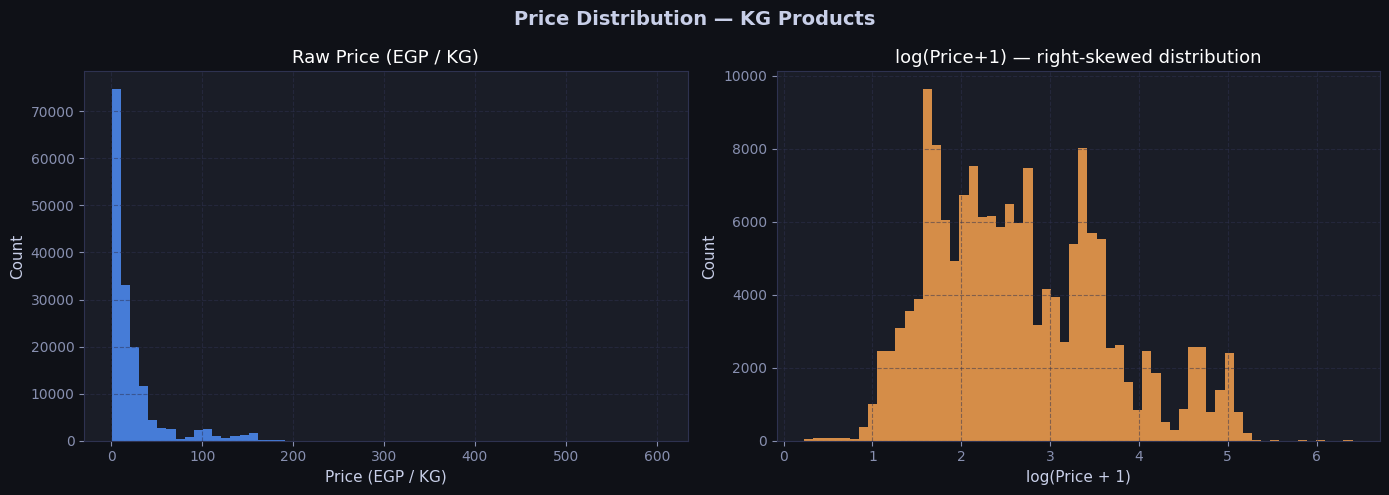

In [98]:
#  KG products 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution — KG Products', fontsize=14, fontweight='bold')

axes[0].hist(df_kg['Price'], bins=60, color=P[0], edgecolor='none', alpha=0.85)
axes[0].set_title('Raw Price (EGP / KG)')
axes[0].set_xlabel('Price (EGP / KG)')
axes[0].set_ylabel('Count')
axes[0].grid(True)

axes[1].hist(np.log1p(df_kg['Price']), bins=60, color=P[1], edgecolor='none', alpha=0.85)
axes[1].set_title('log(Price+1) — right-skewed distribution')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
savefig('01_distribution_kg')
plt.show()

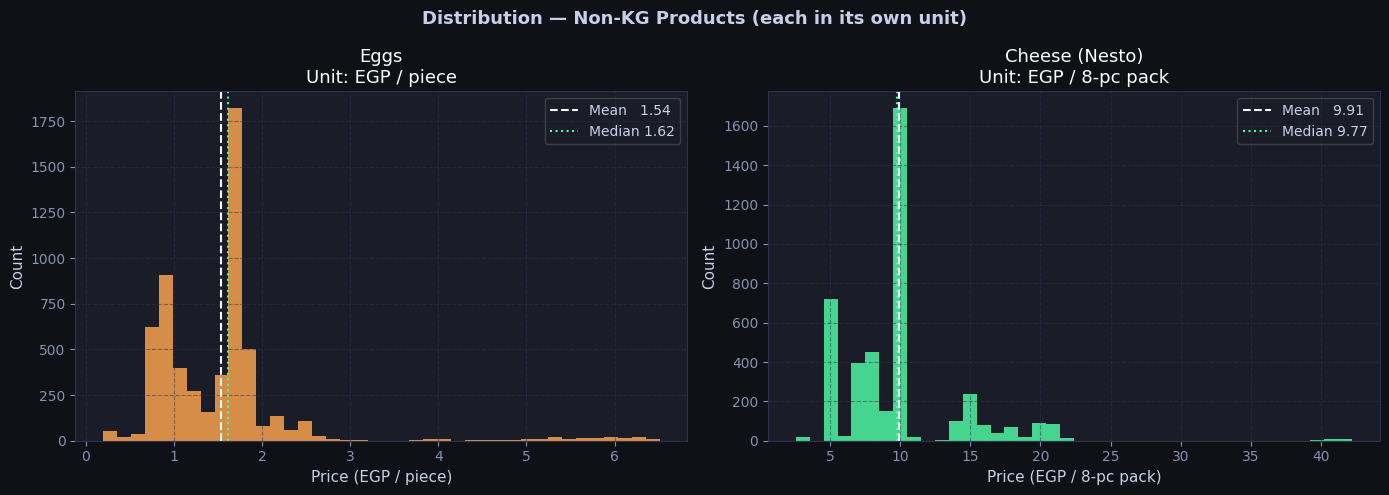

In [99]:
#  Eggs & Cheese — each in its own unit 
groups = []
if len(df_egg)  > 0: groups.append((df_egg,  'Eggs',           'EGP / piece',    P[1]))
if len(df_pack) > 0: groups.append((df_pack, 'Cheese (Nesto)', 'EGP / 8-pc pack',P[2]))

if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(7*len(groups), 5))
    if len(groups) == 1: axes = [axes]
    for ax, (sub, label, unit, color) in zip(axes, groups):
        v = sub['Price']
        ax.hist(v, bins=40, color=color, edgecolor='none', alpha=0.85)
        ax.axvline(v.mean(),   color='white', lw=1.5, ls='--', label=f'Mean   {v.mean():.2f}')
        ax.axvline(v.median(), color=P[2],    lw=1.5, ls=':',  label=f'Median {v.median():.2f}')
        ax.set_title(f'{label}\nUnit: {unit}')
        ax.set_xlabel(f'Price ({unit})')
        ax.set_ylabel('Count')
        ax.legend(framealpha=0.2)
        ax.grid(True)
    fig.suptitle('Distribution — Non-KG Products (each in its own unit)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('02_distribution_nonkg')
    plt.show()

## 5. Outlier Detection — Boxplot per Product

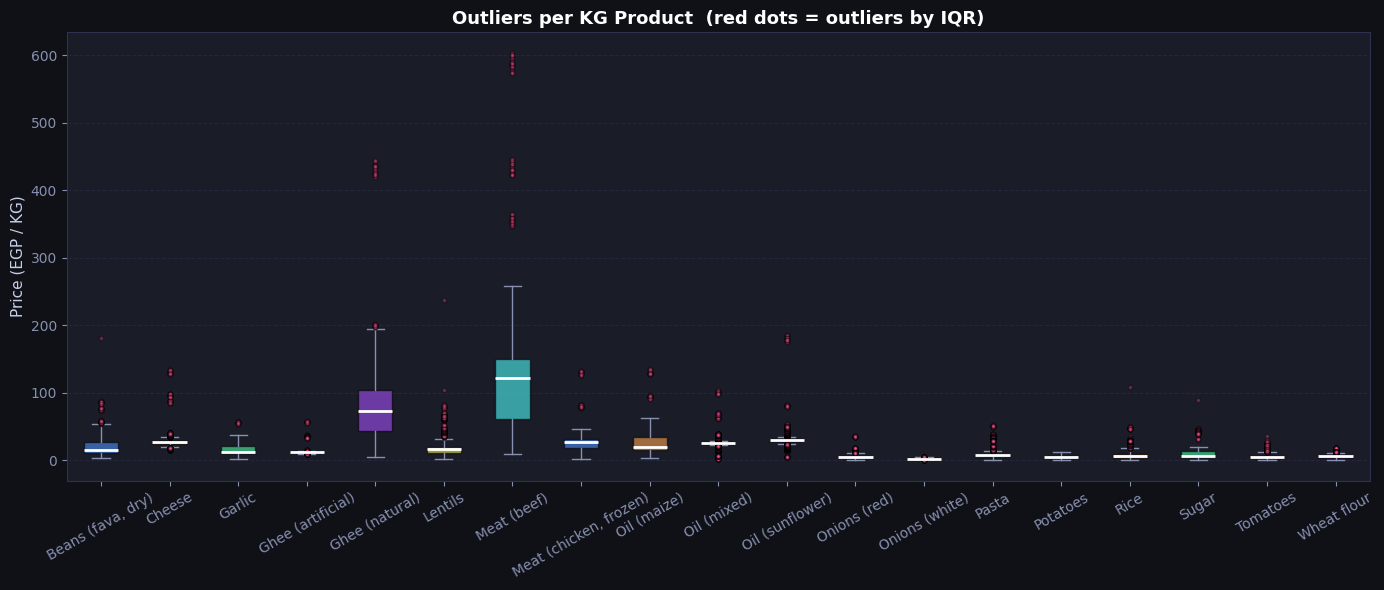

In [100]:
#  KG products boxplot 
products_kg  = sorted(df_kg['Product'].unique())
data_kg      = [df_kg[df_kg['Product'] == p]['Price'].values for p in products_kg]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    data_kg, patch_artist=True, labels=products_kg,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#8890b0'),
    capprops=dict(color='#8890b0'),
    flierprops=dict(marker='o', markerfacecolor=P[3],
                    alpha=0.35, markersize=3, linestyle='none')
)
for patch, c in zip(bp['boxes'], P * 5):
    patch.set_facecolor(c); patch.set_alpha(0.6)

ax.set_title('Outliers per KG Product  (red dots = outliers by IQR)', fontweight='bold')
ax.set_ylabel('Price (EGP / KG)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y')
plt.tight_layout()
savefig('03_outliers_kg')
plt.show()

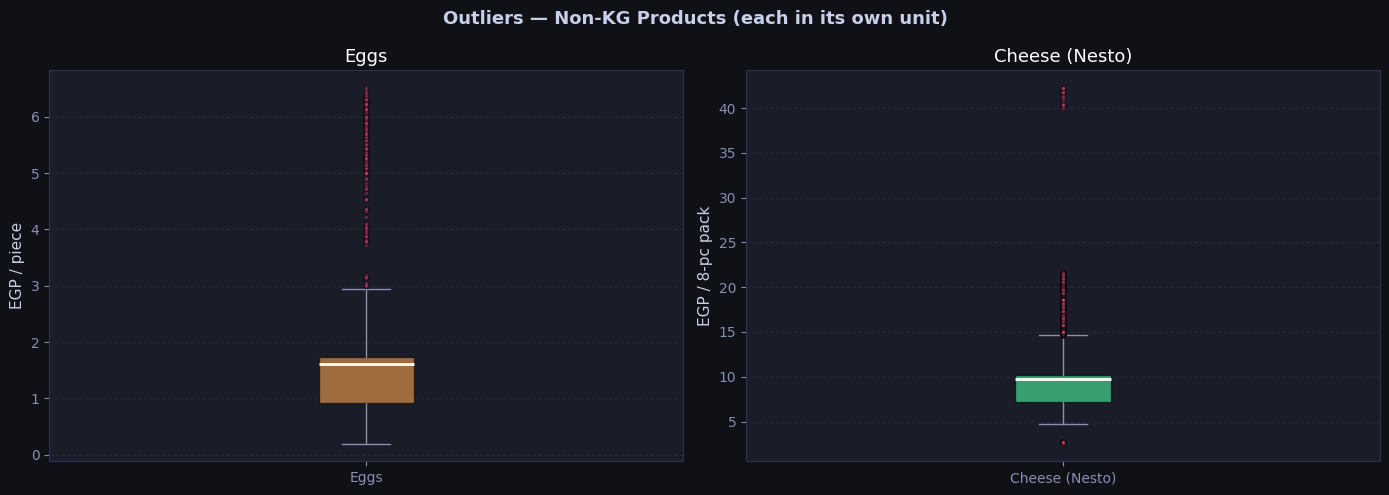

In [103]:
#  Eggs & Cheese boxplots (separate, own units) 
if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(7*len(groups), 5))
    if len(groups) == 1: axes = [axes]
    for ax, (sub, label, unit, color) in zip(axes, groups):
        bp = ax.boxplot(
            [sub['Price'].values], patch_artist=True, labels=[label],
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color='#8890b0'),
            capprops=dict(color='#8890b0'),
            flierprops=dict(marker='o', markerfacecolor=P[3],
                            alpha=0.35, markersize=3, linestyle='none')
        )
        bp['boxes'][0].set_facecolor(color); bp['boxes'][0].set_alpha(0.6)
        ax.set_title(f'{label}')
        ax.set_ylabel(unit)
        ax.grid(True, axis='y')
    fig.suptitle('Outliers — Non-KG Products (each in its own unit)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('04_outliers_nonkg')
    plt.show()

In [104]:
# Outlier summary table — ALL product groups
rows = []
for label, sub in [('KG', df_kg), ('per piece', df_egg), ('per pack', df_pack)]:
    if len(sub) == 0: continue
    for prod, grp in sub.groupby('Product'):
        s = grp['Price']
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        out = s[(s < Q1-1.5*IQR) | (s > Q3+1.5*IQR)]
        rows.append({'Product': prod, 'Unit': label, 'Total': len(s),
                     'Outliers': len(out),
                     'Outlier_%': round(len(out)/len(s)*100, 1),
                     'IQR_range': f'{Q1-1.5*IQR:.1f} – {Q3+1.5*IQR:.1f}'})

outlier_summary = pd.DataFrame(rows).sort_values('Outlier_%', ascending=False)
print('=== OUTLIER SUMMARY (ALL PRODUCTS) ===')
print(outlier_summary.to_string(index=False))

=== OUTLIER SUMMARY (ALL PRODUCTS) ===
               Product      Unit  Total  Outliers  Outlier_%     IQR_range
       Oil (sunflower)        KG   5400      1866       34.6   24.6 – 35.3
           Oil (mixed)        KG   4860      1478       30.4   22.2 – 29.2
                Cheese        KG   6480      1402       21.6   19.2 – 34.7
        Cheese (picon)  per pack   4230       615       14.5    2.7 – 14.7
     Ghee (artificial)        KG   3690       253        6.9   10.2 – 14.6
              Tomatoes        KG   9040       333        3.7   -2.0 – 11.8
           Wheat flour        KG  12420       447        3.6   -0.1 – 11.5
                  Eggs per piece   5755       200        3.5    -0.3 – 3.0
                 Pasta        KG  11480       375        3.3   -1.1 – 13.9
               Lentils        KG  11085       304        2.7   -2.3 – 34.1
        Onions (white)        KG   4500       104        2.3     0.6 – 4.5
                  Rice        KG  12260       257        2.1 

## 6. Average Price by Category & Product

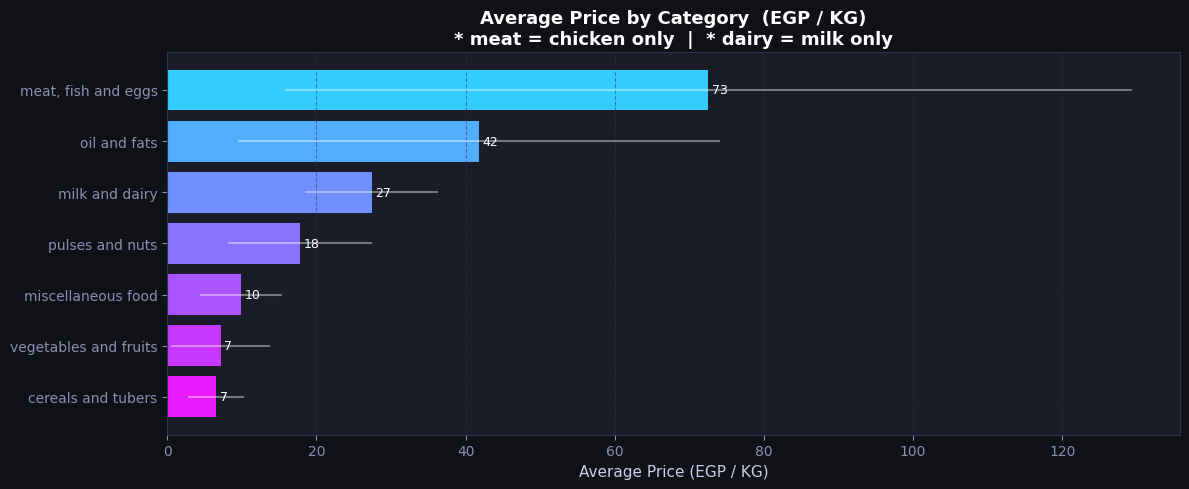

             Category  mean  median   std
  meat, fish and eggs 72.56   56.99 56.78
         oil and fats 41.77   31.23 32.34
       milk and dairy 27.39   27.56  8.94
      pulses and nuts 17.77   15.11  9.68
   miscellaneous food  9.85    6.82  5.51
vegetables and fruits  7.15    5.00  6.65
   cereals and tubers  6.57    5.80  3.76


In [ ]:
#  By category (KG only) 
cat_stats = (
    df_kg.groupby('Category')['Price']
         .agg(['mean','median','std'])
         .sort_values('mean', ascending=False).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.cool(np.linspace(0.2, 0.9, len(cat_stats)))
bars = ax.barh(cat_stats['Category'], cat_stats['mean'],
               color=colors, edgecolor='none')
ax.errorbar(cat_stats['mean'], cat_stats['Category'],
            xerr=cat_stats['std'], fmt='none',
            color='white', alpha=0.4, linewidth=1.5)
for bar, val in zip(bars, cat_stats['mean']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9, color='white')
ax.set_title('Average Price by Category  (EGP / KG)\n'
             '* meat = chicken only  |  * dairy = milk only',
             fontweight='bold')
ax.set_xlabel('Average Price (EGP / KG)')
ax.invert_yaxis()
ax.grid(True, axis='x')
plt.tight_layout()
savefig('05_avg_by_category_kg')
plt.show()
print(cat_stats.round(2).to_string(index=False))

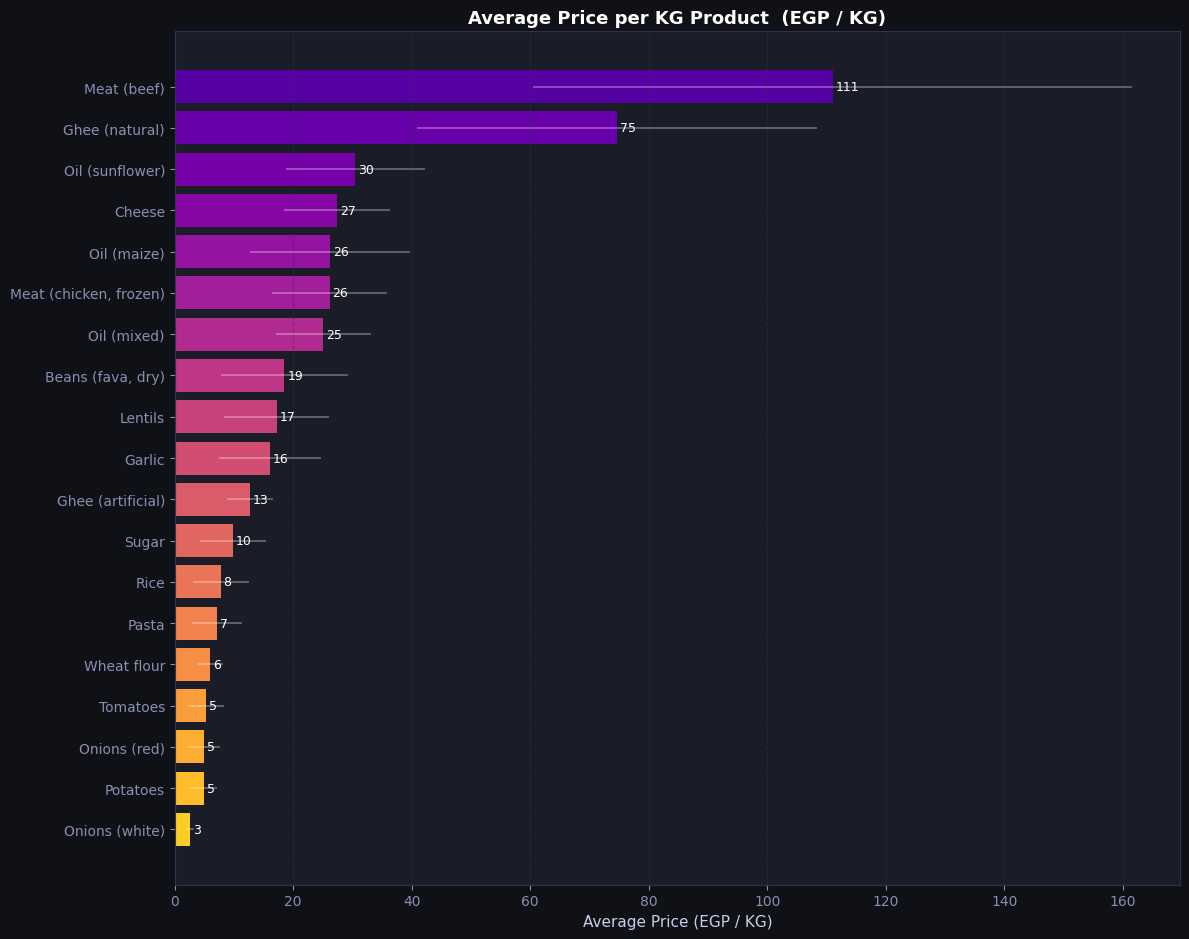

In [108]:
#  By individual KG product 
prod_stats = (
    df_kg.groupby('Product')['Price']
         .agg(['mean','median','std'])
         .sort_values('mean', ascending=False).reset_index()
)

fig, ax = plt.subplots(figsize=(12, max(5, len(prod_stats)*0.5)))
colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(prod_stats)))
bars = ax.barh(prod_stats['Product'], prod_stats['mean'],
               color=colors, edgecolor='none')
ax.errorbar(prod_stats['mean'], prod_stats['Product'],
            xerr=prod_stats['std'], fmt='none',
            color='white', alpha=0.35, linewidth=1.2)
for bar, val in zip(bars, prod_stats['mean']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9, color='white')
ax.set_title('Average Price per KG Product  (EGP / KG)', fontweight='bold')
ax.set_xlabel('Average Price (EGP / KG)')
ax.invert_yaxis()
ax.grid(True, axis='x')
plt.tight_layout()
savefig('06_avg_per_product_kg')
plt.show()

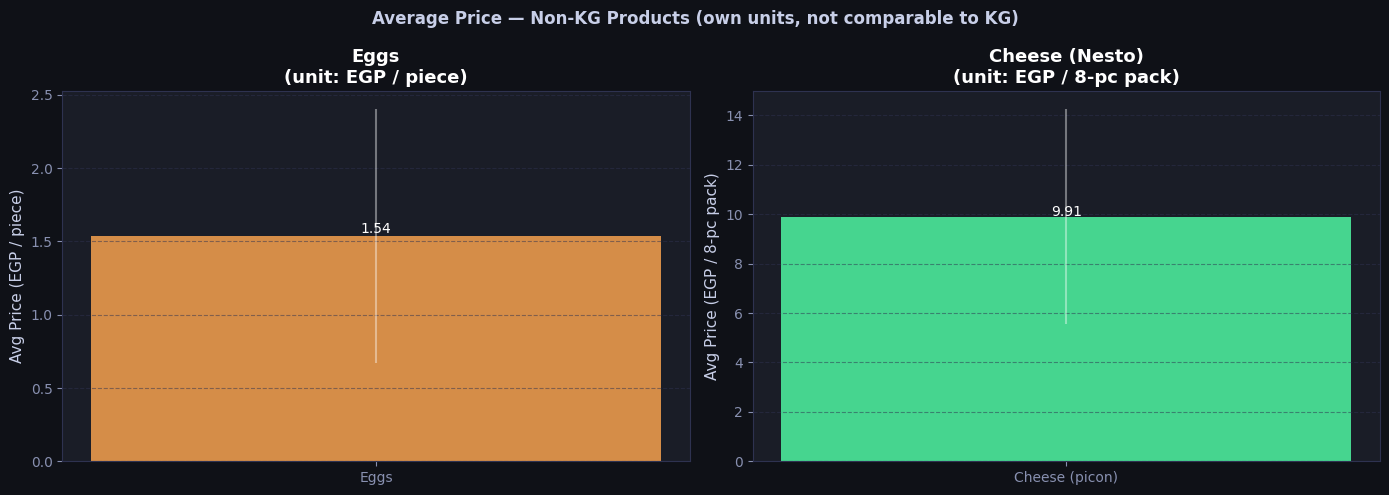

In [109]:
#  Eggs & Cheese average (their own units) 
if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(7*len(groups), 5))
    if len(groups) == 1: axes = [axes]
    for ax, (sub, label, unit, color) in zip(axes, groups):
        stats = sub.groupby('Product')['Price'].agg(['mean','std']).reset_index()
        bars  = ax.bar(stats['Product'], stats['mean'],
                       color=color, edgecolor='none', alpha=0.85)
        ax.errorbar(stats['Product'], stats['mean'],
                    yerr=stats['std'], fmt='none',
                    color='white', alpha=0.4, linewidth=1.5)
        for bar, val in zip(bars, stats['mean']):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.02,
                    f'{val:.2f}', ha='center', fontsize=10, color='white')
        ax.set_title(f'{label}\n(unit: {unit})', fontweight='bold')
        ax.set_ylabel(f'Avg Price ({unit})')
        ax.grid(True, axis='y')
    fig.suptitle('Average Price — Non-KG Products (own units, not comparable to KG)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('07_avg_nonkg')
    plt.show()

## 7. Price Trends Over Time

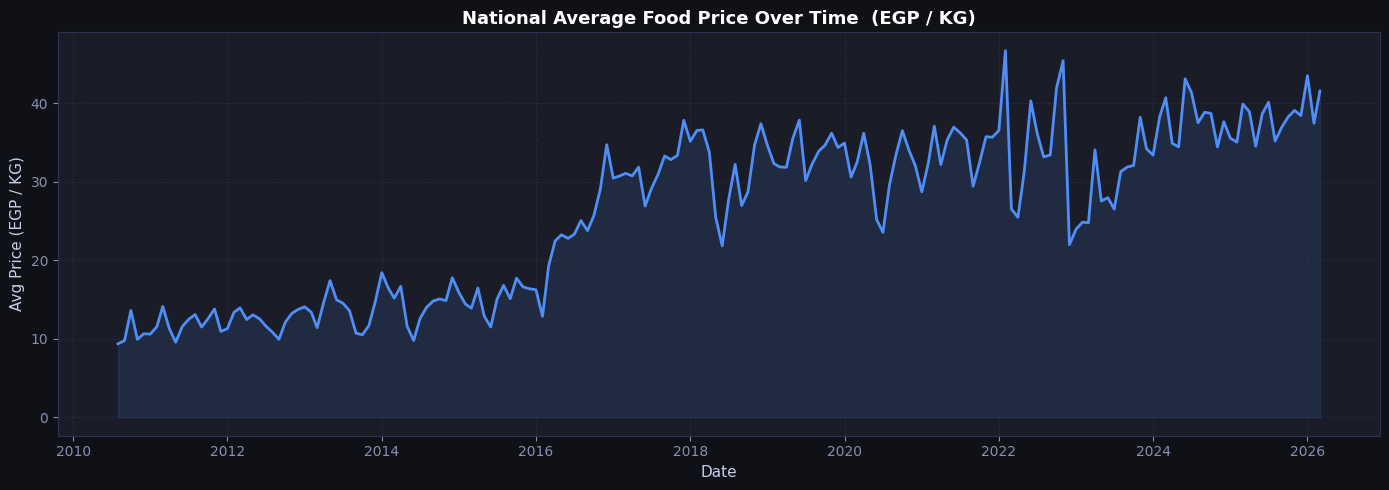

In [110]:
#  National average (KG) 
monthly = df_kg.groupby('Date')['Price'].mean().reset_index().sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly['Date'], monthly['Price'], alpha=0.12, color=P[0])
ax.plot(monthly['Date'], monthly['Price'], color=P[0], linewidth=2)
ax.set_title('National Average Food Price Over Time  (EGP / KG)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Price (EGP / KG)')
ax.grid(True)
plt.tight_layout()
savefig('08_national_trend_kg')
plt.show()

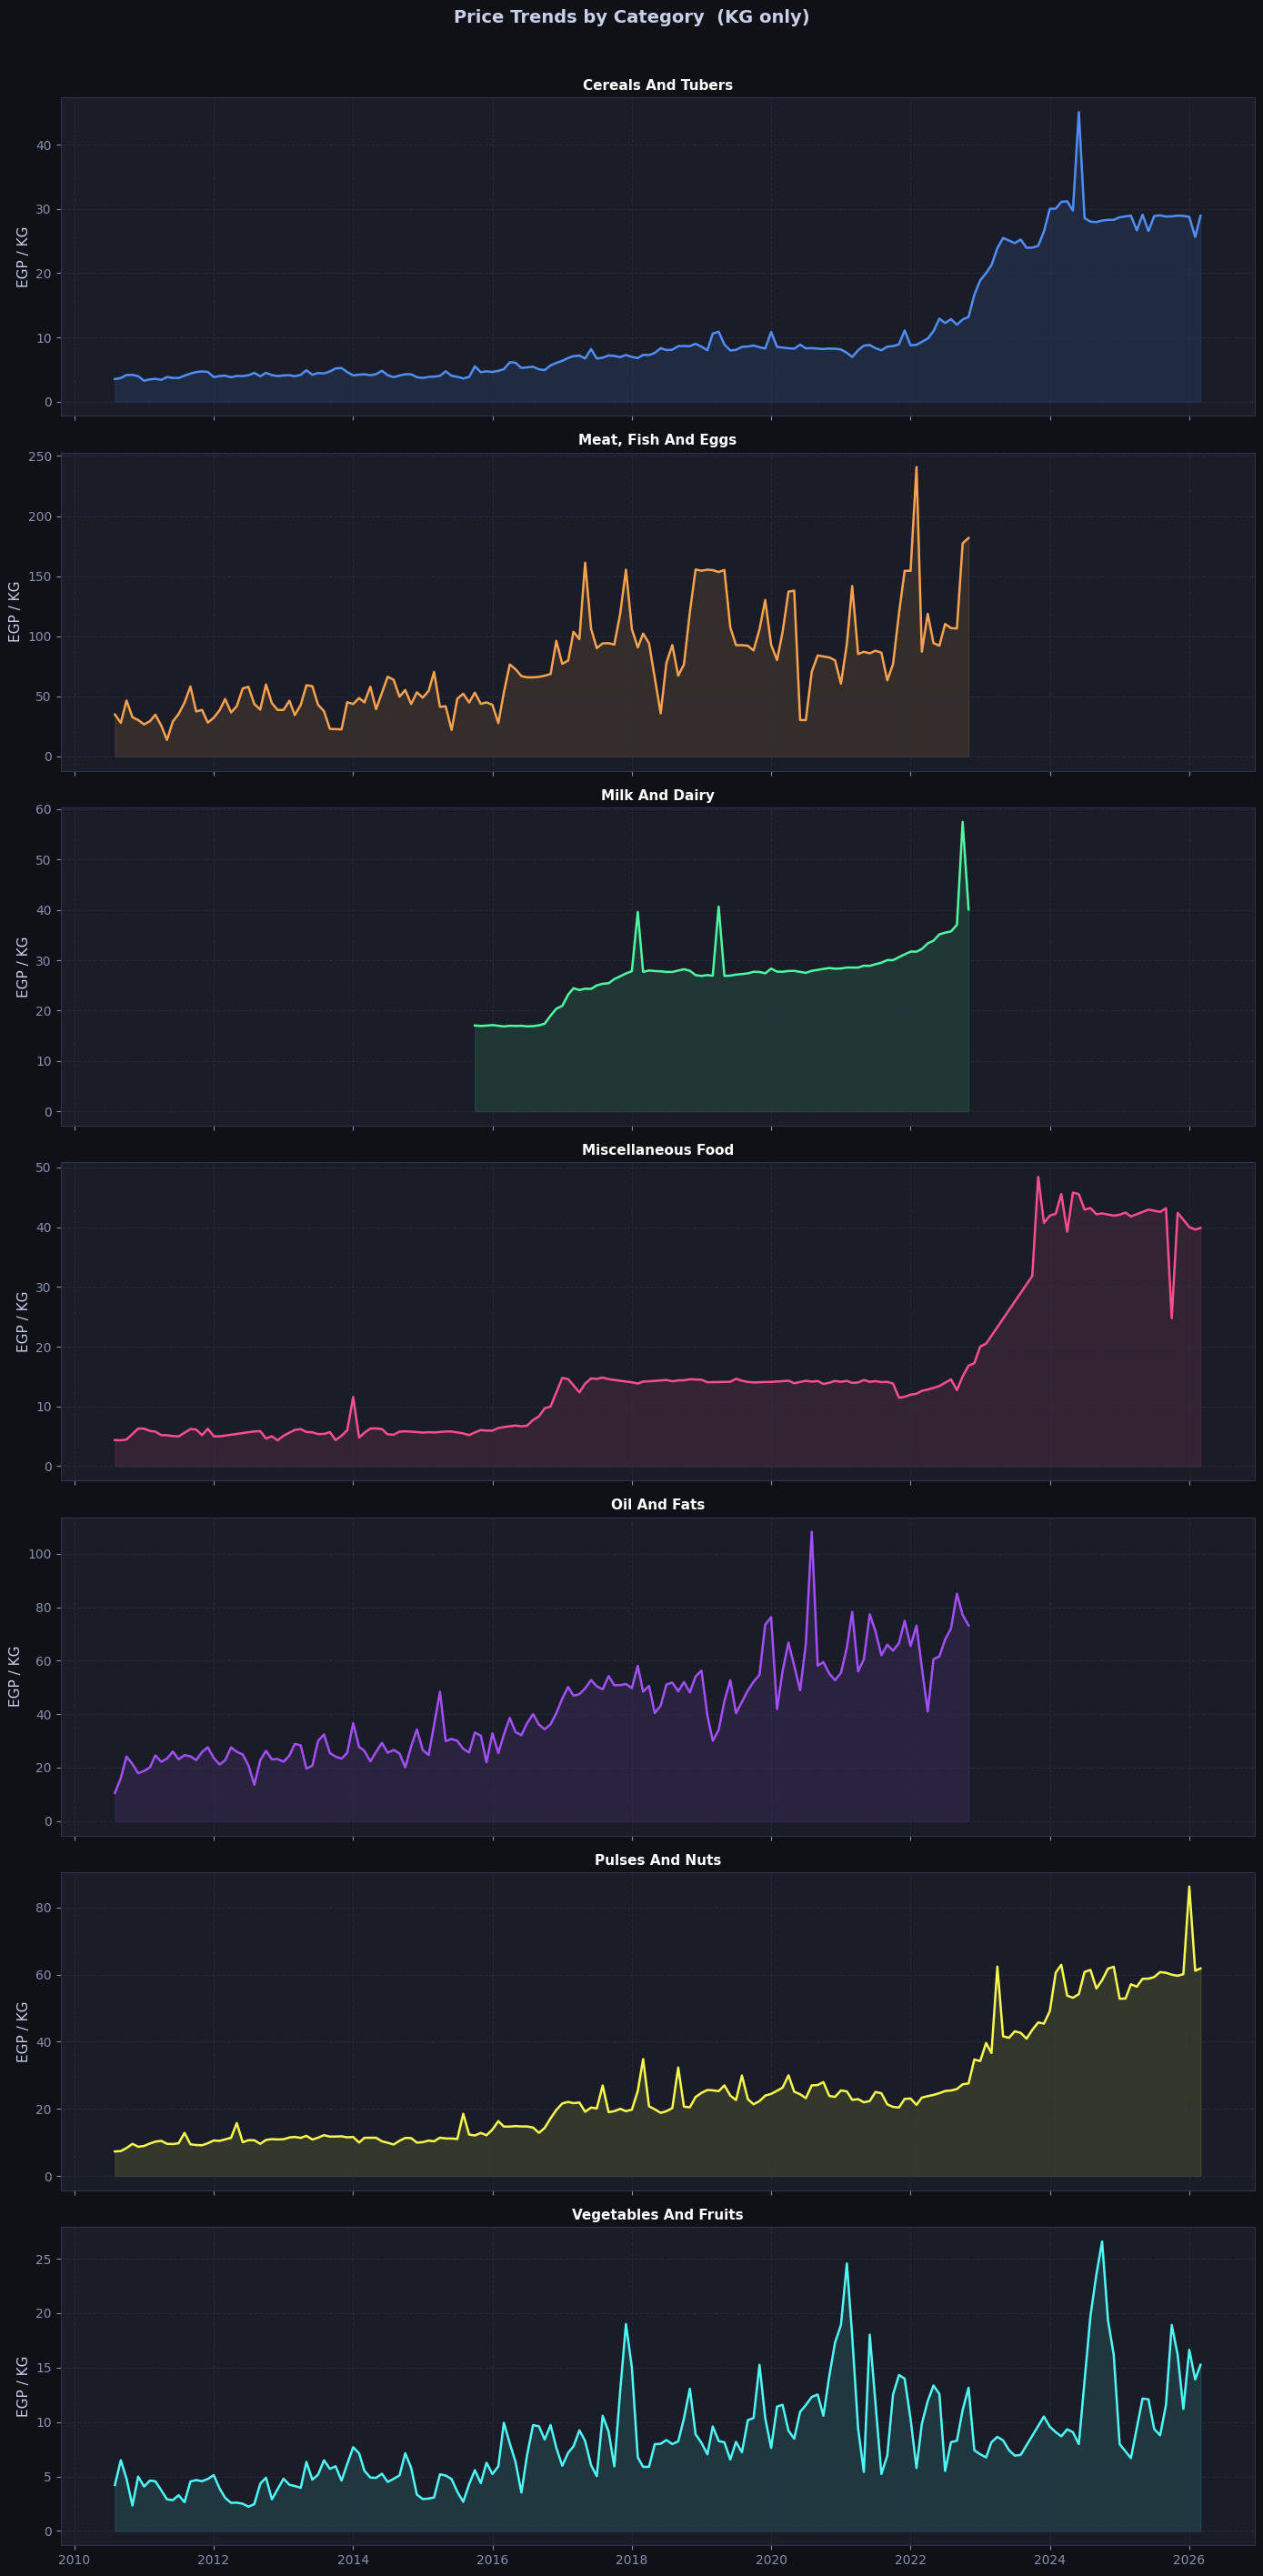

In [111]:
#  Trend per category (KG) 
cat_monthly = df_kg.groupby(['Date','Category'])['Price'].mean().reset_index()
cats = sorted(cat_monthly['Category'].unique())

fig, axes = plt.subplots(len(cats), 1, figsize=(14, 4*len(cats)), sharex=True)
if len(cats) == 1: axes = [axes]

for ax, cat, c in zip(axes, cats, P*5):
    sub = cat_monthly[cat_monthly['Category'] == cat].sort_values('Date')
    ax.fill_between(sub['Date'], sub['Price'], alpha=0.12, color=c)
    ax.plot(sub['Date'], sub['Price'], color=c, linewidth=1.8)
    ax.set_title(cat.title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('EGP / KG')
    ax.grid(True)

fig.suptitle('Price Trends by Category  (KG only)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('09_trend_by_category_kg')
plt.show()

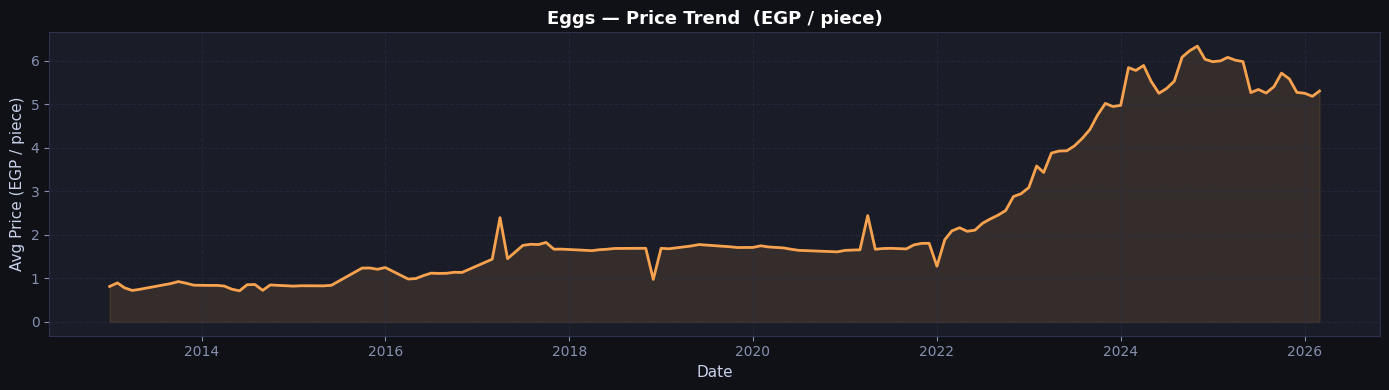

In [112]:
#  Eggs trend (EGP / piece) 
if len(df_egg) > 0:
    t = df_egg.groupby('Date')['Price'].mean().reset_index().sort_values('Date')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(t['Date'], t['Price'], alpha=0.12, color=P[1])
    ax.plot(t['Date'], t['Price'], color=P[1], linewidth=2)
    ax.set_title('Eggs — Price Trend  (EGP / piece)', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Price (EGP / piece)')
    ax.grid(True)
    plt.tight_layout()
    savefig('10_trend_eggs')
    plt.show()

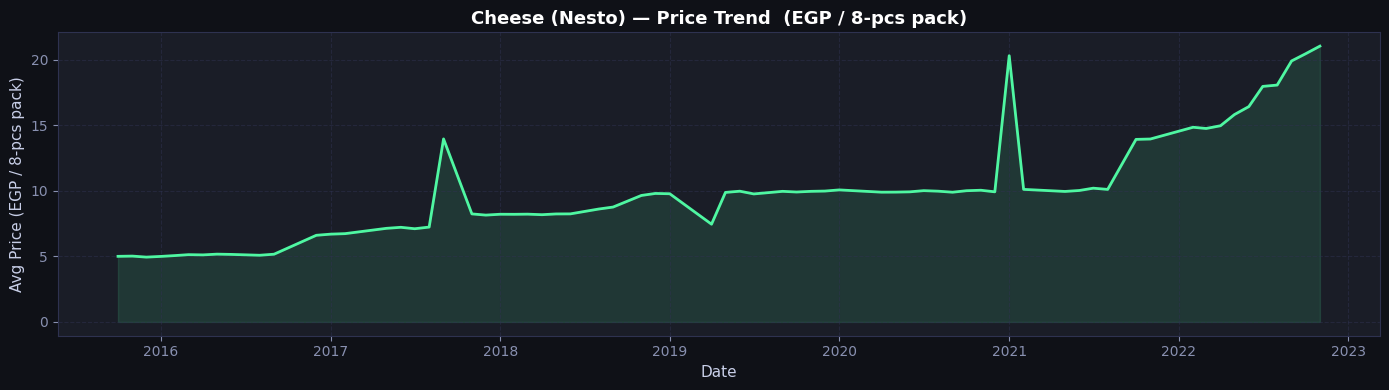

In [113]:
#  Cheese trend (EGP / 8-pc pack) 
if len(df_pack) > 0:
    t = df_pack.groupby('Date')['Price'].mean().reset_index().sort_values('Date')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(t['Date'], t['Price'], alpha=0.12, color=P[2])
    ax.plot(t['Date'], t['Price'], color=P[2], linewidth=2)
    ax.set_title('Cheese (Nesto) — Price Trend  (EGP / 8-pcs pack)', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Price (EGP / 8-pcs pack)')
    ax.grid(True)
    plt.tight_layout()
    savefig('11_trend_cheese')
    plt.show()

## 8. Year-over-Year Inflation

$$\text{YoY \%} = \left( \frac{\text{Price}_{\text{current year}} - \text{Price}_{\text{previous year}}}{\text{Price}_{\text{previous year}}} \right) \times 100$$

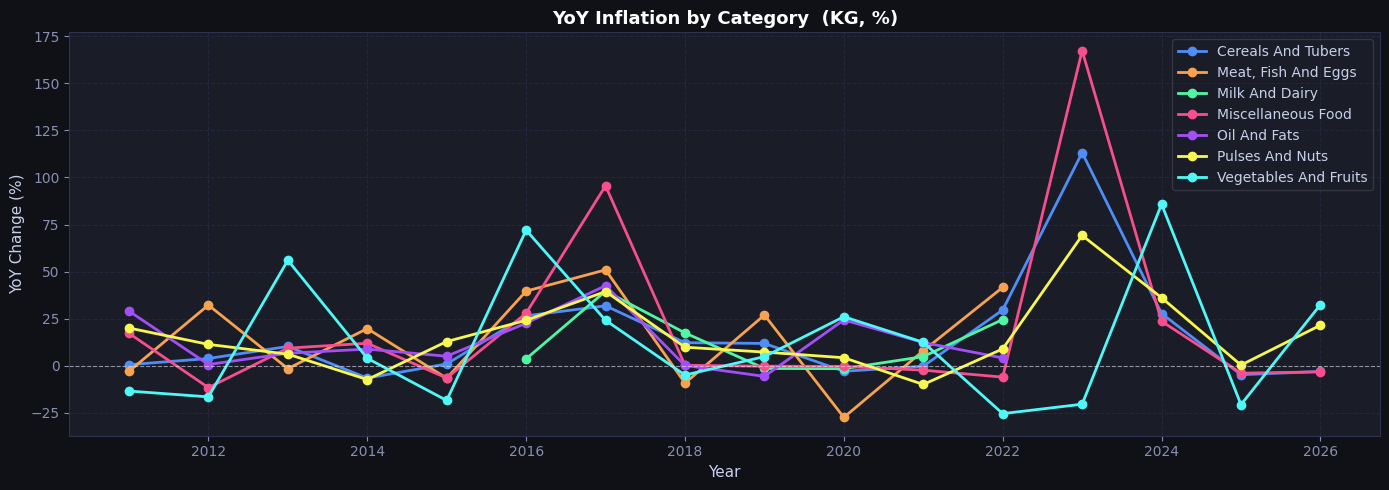

Category  cereals and tubers  meat, fish and eggs  milk and dairy  miscellaneous food  oil and fats  pulses and nuts  vegetables and fruits
Year                                                                                                                                       
2010                     NaN                  NaN             NaN                 NaN           NaN              NaN                    NaN
2011                     0.5                 -3.0             NaN                17.2          29.0             20.0                  -13.5
2012                     3.8                 32.2             NaN               -11.7           0.6             11.3                  -16.6
2013                    10.2                 -1.6             NaN                 9.3           6.6              6.1                   56.0
2014                    -6.6                 19.7             NaN                11.9           8.8             -7.4                    3.9
2015                

In [114]:
#  KG categories 
yearly_cat = (
    df_kg.groupby(['Year','Category'])['Price'].mean()
         .reset_index().sort_values(['Category','Year'])
)
yearly_cat['YoY_%'] = (
    yearly_cat.groupby('Category')['Price'].pct_change() * 100
).round(1)

inf_pivot = yearly_cat.pivot(index='Year', columns='Category', values='YoY_%')

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(inf_pivot.columns):
    ax.plot(inf_pivot.index, inf_pivot[col], marker='o', linewidth=2,
            label=col.title(), color=P[i % len(P)])
ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_title('YoY Inflation by Category  (KG, %)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('YoY Change (%)')
ax.legend(framealpha=0.15)
ax.grid(True)
plt.tight_layout()
savefig('12_yoy_category_kg')
plt.show()
print(inf_pivot.round(1).to_string())

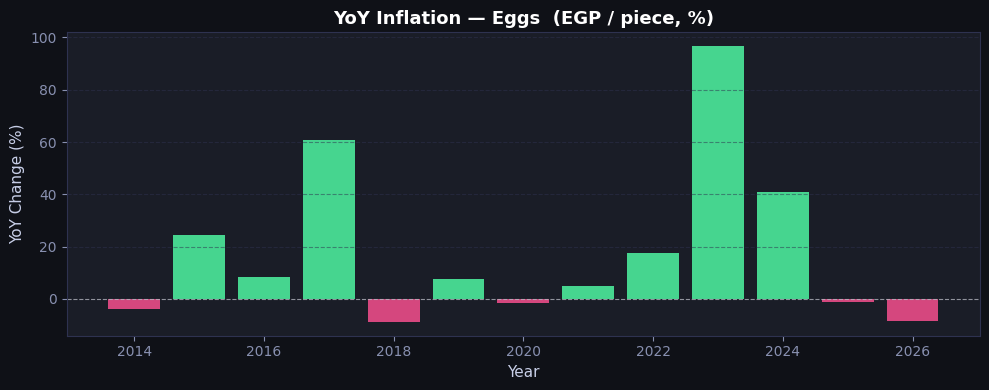

 Year  Price  YoY_%
 2013   0.84    NaN
 2014   0.81   -3.7
 2015   1.01   24.5
 2016   1.09    8.2
 2017   1.75   60.8
 2018   1.60   -8.8
 2019   1.72    7.5
 2020   1.69   -1.6
 2021   1.77    4.8
 2022   2.08   17.6
 2023   4.10   96.7
 2024   5.77   40.8
 2025   5.70   -1.2
 2026   5.23   -8.3


In [115]:
#  YoY for Eggs 
if len(df_egg) > 0:
    ye = (
        df_egg.groupby('Year')['Price'].mean()
              .reset_index().sort_values('Year')
    )
    ye['YoY_%'] = (ye['Price'].pct_change() * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 4))
    colors_bar = [P[2] if v >= 0 else P[3] for v in ye['YoY_%'].fillna(0)]
    ax.bar(ye['Year'], ye['YoY_%'], color=colors_bar, edgecolor='none', alpha=0.85)
    ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('YoY Inflation — Eggs  (EGP / piece, %)', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('YoY Change (%)')
    ax.grid(True, axis='y')
    plt.tight_layout()
    savefig('13_yoy_eggs')
    plt.show()
    print(ye.round(2).to_string(index=False))

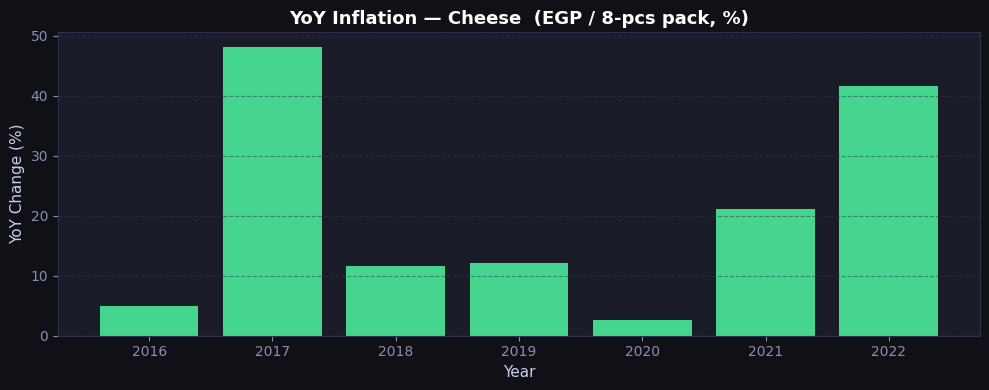

 Year  Price  YoY_%
 2015   4.99    NaN
 2016   5.23    4.9
 2017   7.75   48.2
 2018   8.66   11.7
 2019   9.71   12.1
 2020   9.97    2.7
 2021  12.09   21.2
 2022  17.13   41.7


In [116]:
#  YoY for Cheese 
if len(df_pack) > 0:
    yc = (
        df_pack.groupby('Year')['Price'].mean()
               .reset_index().sort_values('Year')
    )
    yc['YoY_%'] = (yc['Price'].pct_change() * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 4))
    colors_bar = [P[2] if v >= 0 else P[3] for v in yc['YoY_%'].fillna(0)]
    ax.bar(yc['Year'], yc['YoY_%'], color=colors_bar, edgecolor='none', alpha=0.85)
    ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('YoY Inflation — Cheese  (EGP / 8-pcs pack, %)', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('YoY Change (%)')
    ax.grid(True, axis='y')
    plt.tight_layout()
    savefig('14_yoy_cheese')
    plt.show()
    print(yc.round(2).to_string(index=False))

## 9. Regional Analysis — Governorates

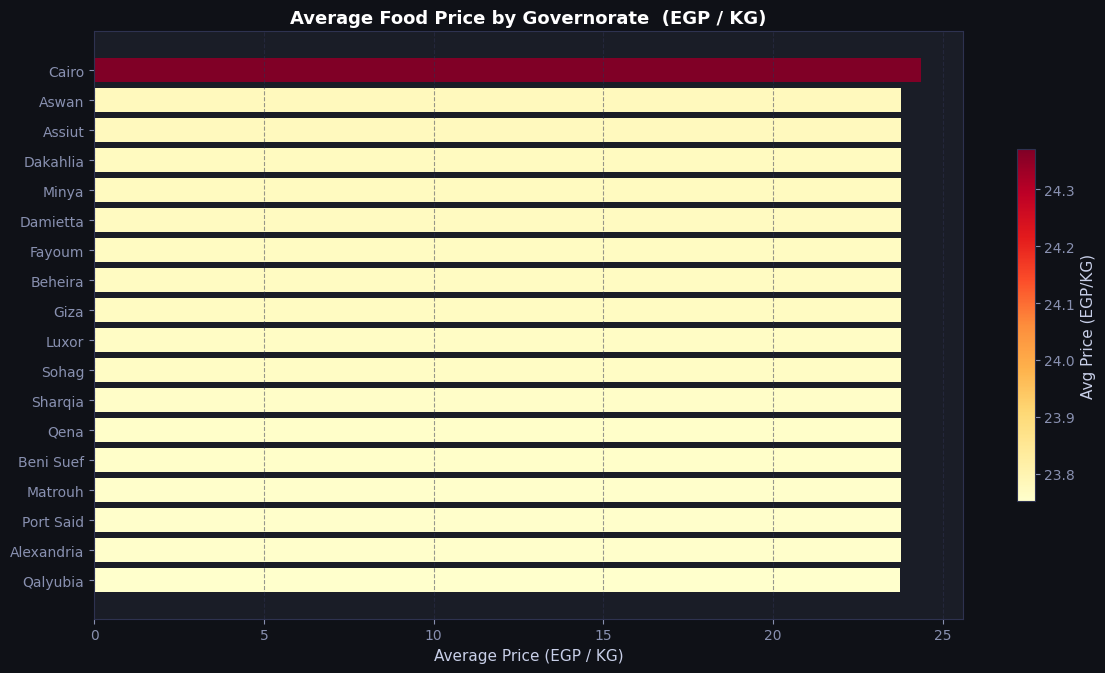

In [117]:
#  KG average per governorate 
gov_kg = df_kg.groupby('Governorate')['Price'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, max(6, len(gov_kg)*0.38)))
norm   = plt.Normalize(gov_kg['Price'].min(), gov_kg['Price'].max())
colors = plt.cm.YlOrRd(norm(gov_kg['Price']))
ax.barh(gov_kg['Governorate'], gov_kg['Price'], color=colors, edgecolor='none')
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Avg Price (EGP/KG)', shrink=0.6)
ax.set_title('Average Food Price by Governorate  (EGP / KG)', fontweight='bold')
ax.set_xlabel('Average Price (EGP / KG)')
ax.invert_yaxis()
ax.grid(True, axis='x')
plt.tight_layout()
savefig('15_governorate_avg_kg')
plt.show()

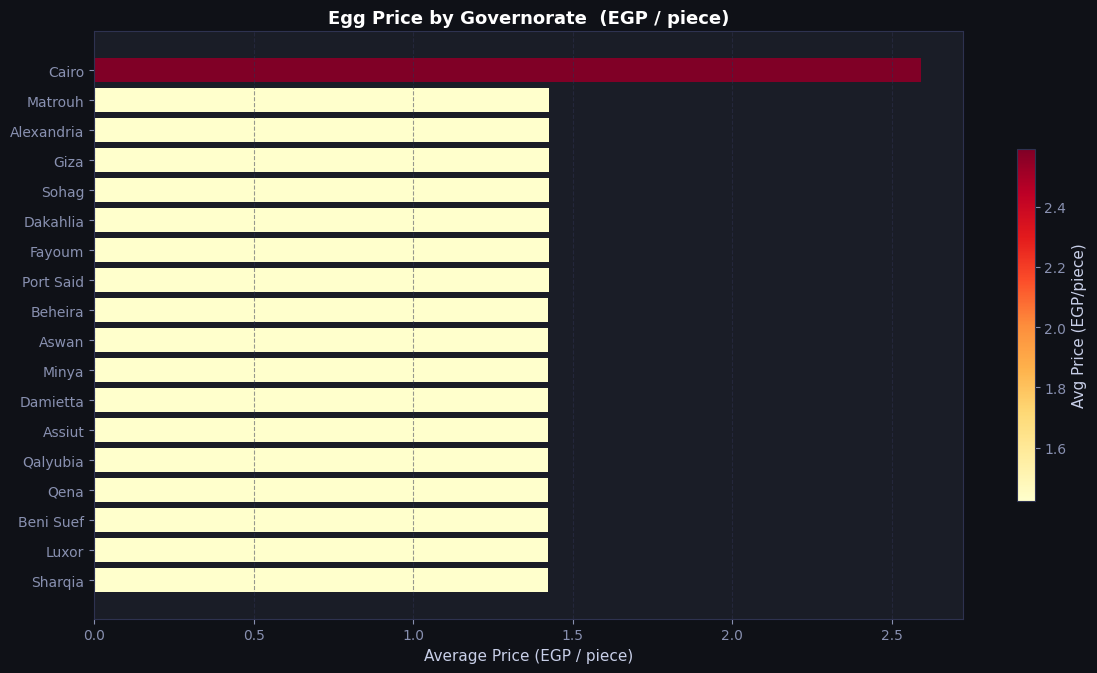

In [118]:
#  Governorate avg for Eggs 
if len(df_egg) > 0 and df_egg['Governorate'].nunique() > 1:
    gov_egg = df_egg.groupby('Governorate')['Price'].mean().sort_values(ascending=False).reset_index()
    fig, ax = plt.subplots(figsize=(12, max(5, len(gov_egg)*0.38)))
    norm   = plt.Normalize(gov_egg['Price'].min(), gov_egg['Price'].max())
    colors = plt.cm.YlOrRd(norm(gov_egg['Price']))
    ax.barh(gov_egg['Governorate'], gov_egg['Price'], color=colors, edgecolor='none')
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Avg Price (EGP/piece)', shrink=0.6)
    ax.set_title('Egg Price by Governorate  (EGP / piece)', fontweight='bold')
    ax.set_xlabel('Average Price (EGP / piece)')
    ax.invert_yaxis()
    ax.grid(True, axis='x')
    plt.tight_layout()
    savefig('16_governorate_eggs')
    plt.show()

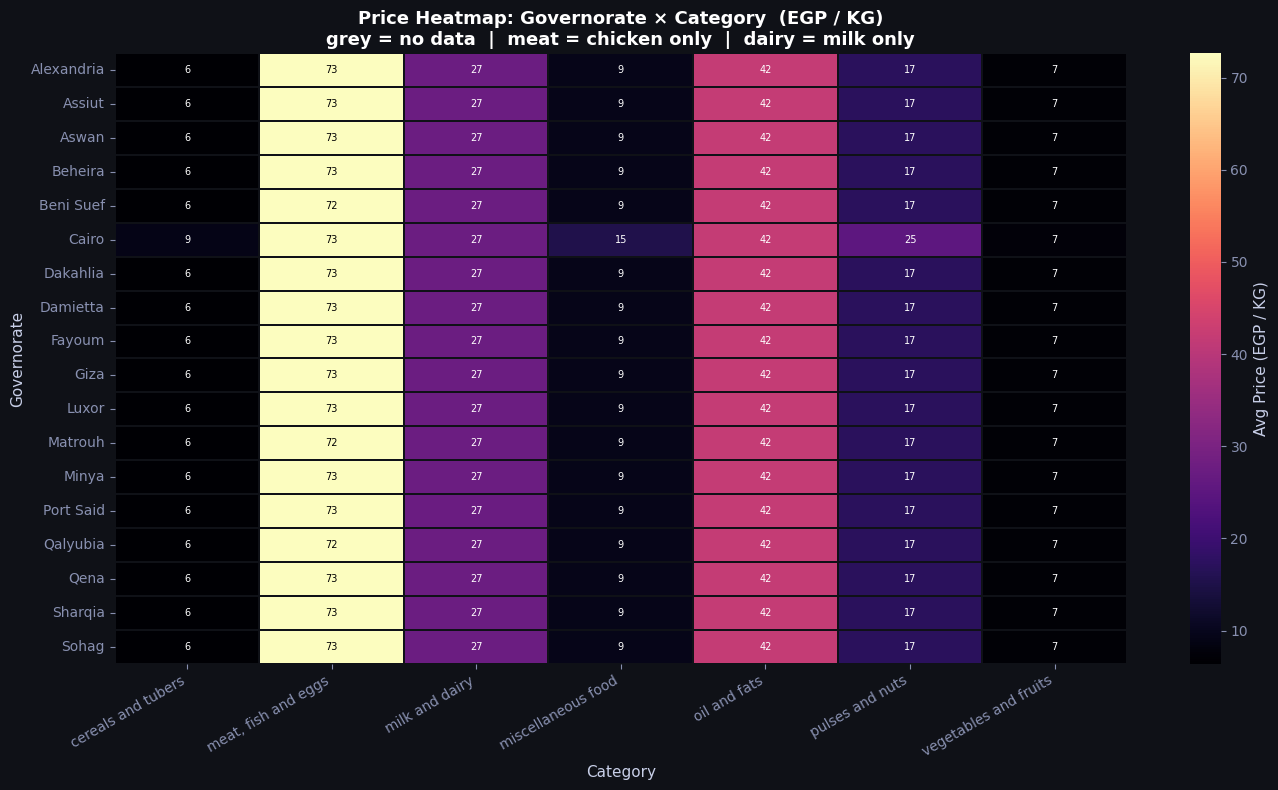

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Heatmap data
hmap = df_kg.groupby(['Governorate','Category'])['Price'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, max(8, len(hmap)*0.38)))

cmap = sns.color_palette("magma", as_cmap=True)

heat = sns.heatmap(
    hmap,
    ax=ax,
    cmap=cmap,
    linewidths=0.3,
    linecolor=BG,
    annot=False,  
    mask=hmap.isnull(),
    cbar_kws={'label': 'Avg Price (EGP / KG)'}
)

for i in range(hmap.shape[0]):
    for j in range(hmap.shape[1]):
        value = hmap.iloc[i, j]

        if not np.isnan(value):
            # normalize value بين 0 و 1
            norm = (value - np.nanmin(hmap.values)) / (np.nanmax(hmap.values) - np.nanmin(hmap.values))

            # اختار لون النص
            text_color = 'black' if norm > 0.6 else 'white'

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.0f}",
                ha='center',
                va='center',
                color=text_color,
                fontsize=7
            )

ax.set_title(
    'Price Heatmap: Governorate × Category  (EGP / KG)\n'
    'grey = no data  |  meat = chicken only  |  dairy = milk only',
    fontweight='bold'
)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()

savefig('17_heatmap_gov_category')
plt.show()

## 10. Seasonality

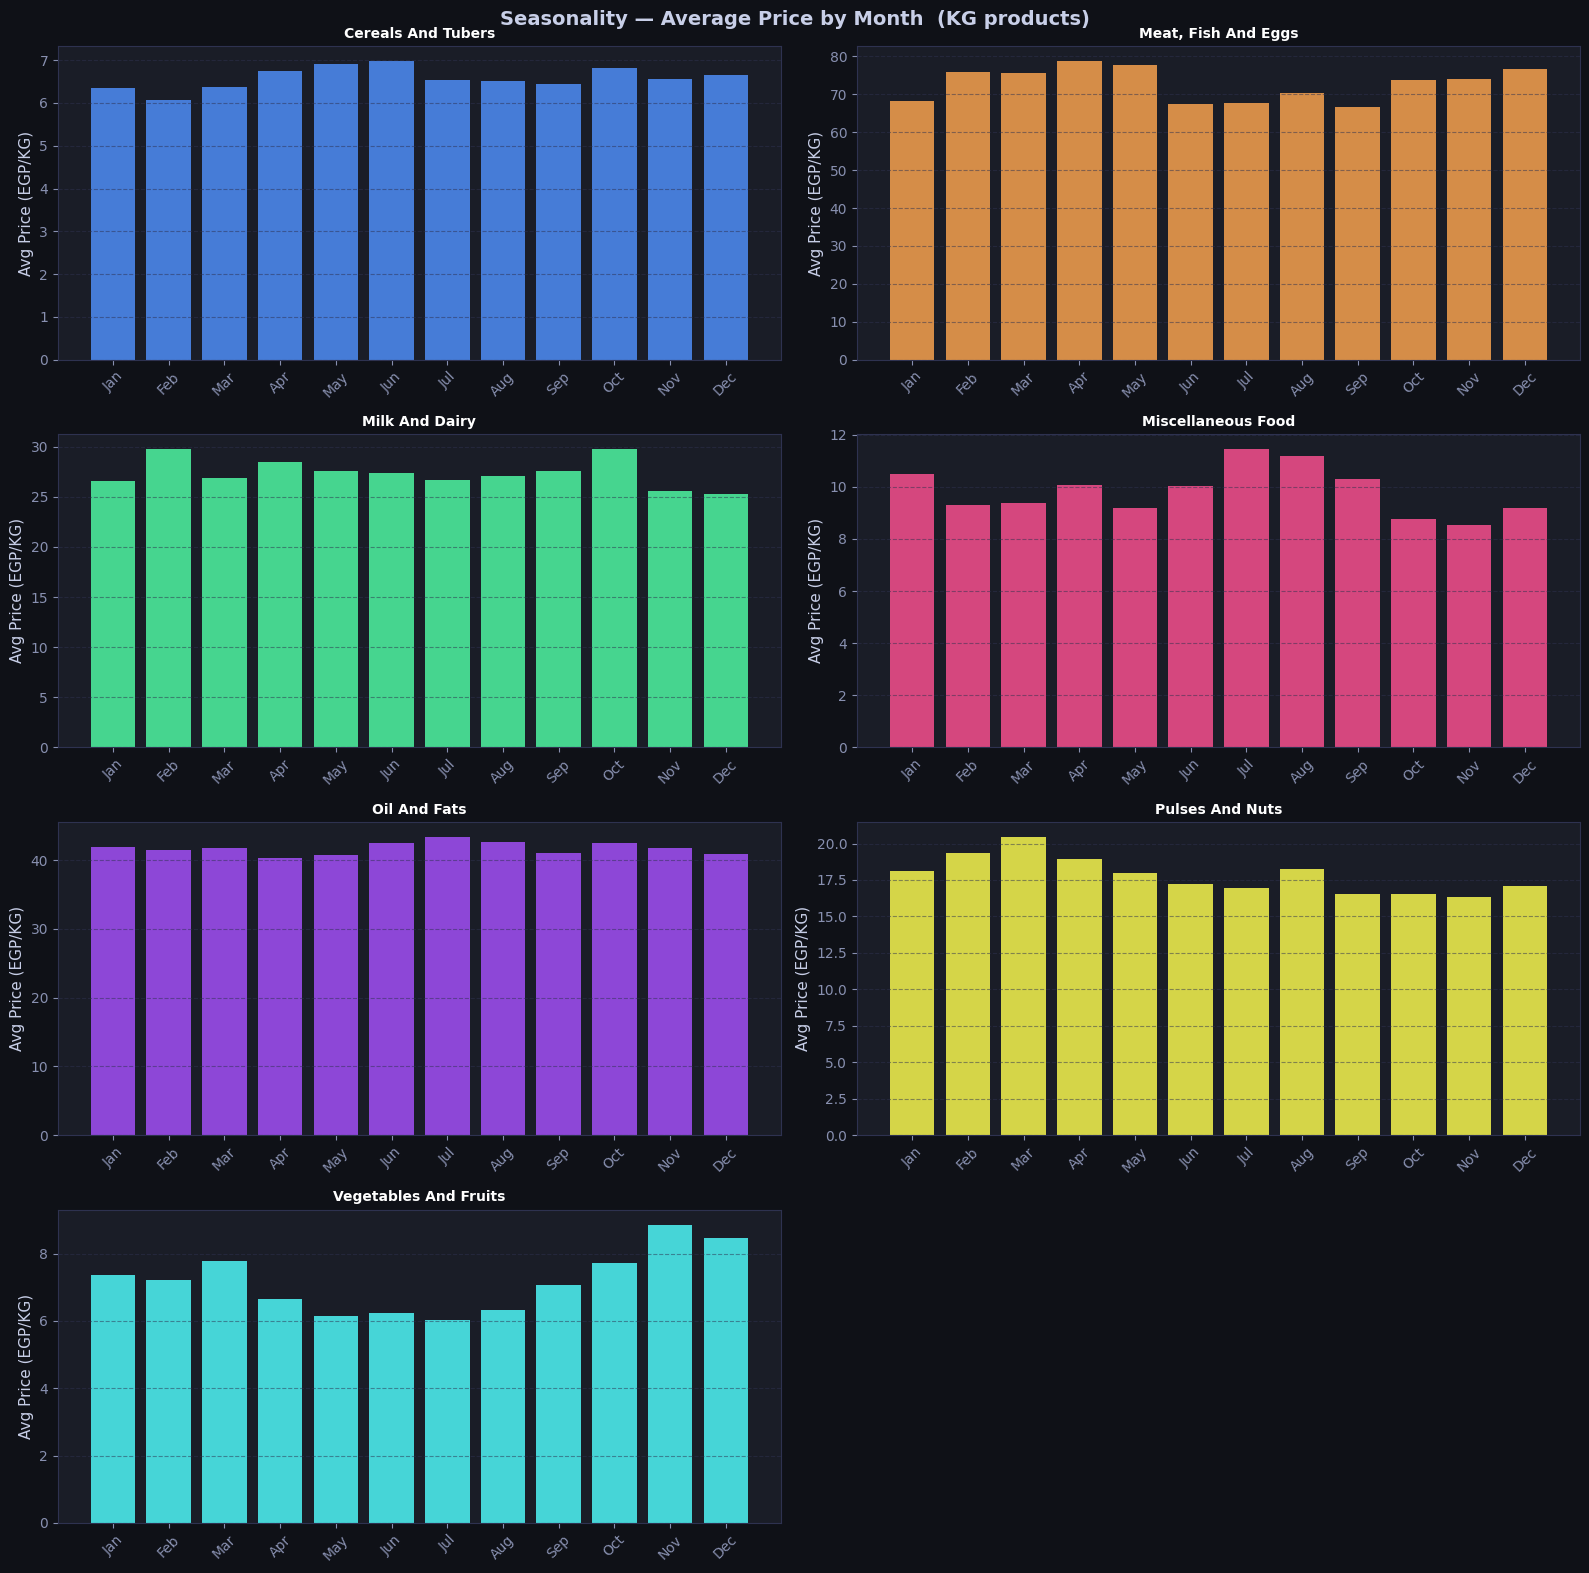

In [124]:
#  KG categories 
seas_kg = df_kg.groupby(['Month','Month_Name','Category'])['Price'].mean().reset_index()
seas_kg['Month_Name'] = pd.Categorical(seas_kg['Month_Name'],
                                       categories=MONTH_ORDER, ordered=True)
seas_kg = seas_kg.sort_values('Month_Name')
cats = sorted(seas_kg['Category'].unique())

ncols = 2
nrows = (len(cats) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for i, cat in enumerate(cats):
    sub = seas_kg[seas_kg['Category'] == cat]
    axes[i].bar(sub['Month_Name'].astype(str), sub['Price'],
                color=P[i % len(P)], alpha=0.85, edgecolor='none')
    axes[i].set_title(cat.title(), fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Avg Price (EGP/KG)')
    axes[i].grid(True, axis='y')

for j in range(i+1, len(axes)): axes[j].set_visible(False)

fig.suptitle('Seasonality — Average Price by Month  (KG products)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('18_seasonality_kg')
plt.show()

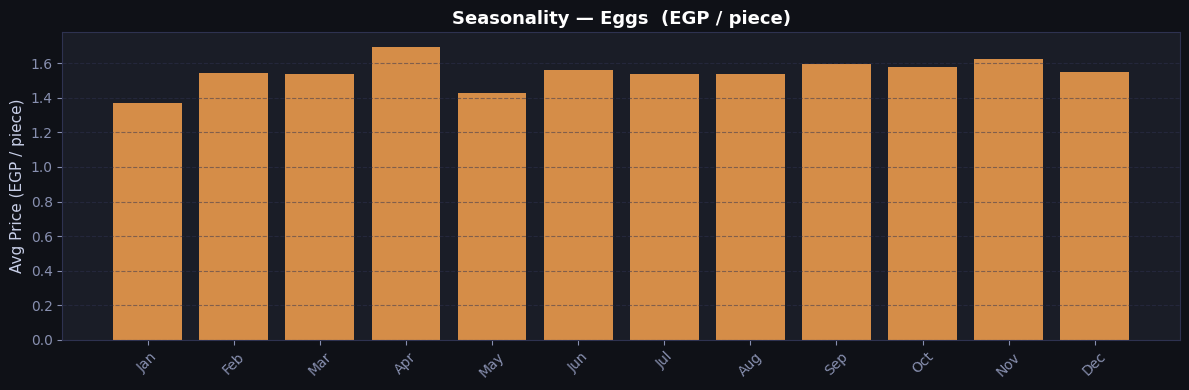

In [126]:
#  Eggs seasonality (EGP / piece) 
if len(df_egg) > 0:
    se = df_egg.groupby(['Month','Month_Name'])['Price'].mean().reset_index()
    se['Month_Name'] = pd.Categorical(se['Month_Name'], categories=MONTH_ORDER, ordered=True)
    se = se.sort_values('Month_Name')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(se['Month_Name'].astype(str), se['Price'],
           color=P[1], alpha=0.85, edgecolor='none')
    ax.set_title('Seasonality — Eggs  (EGP / piece)', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Avg Price (EGP / piece)')
    ax.grid(True, axis='y')
    plt.tight_layout()
    savefig('19_seasonality_eggs')
    plt.show()

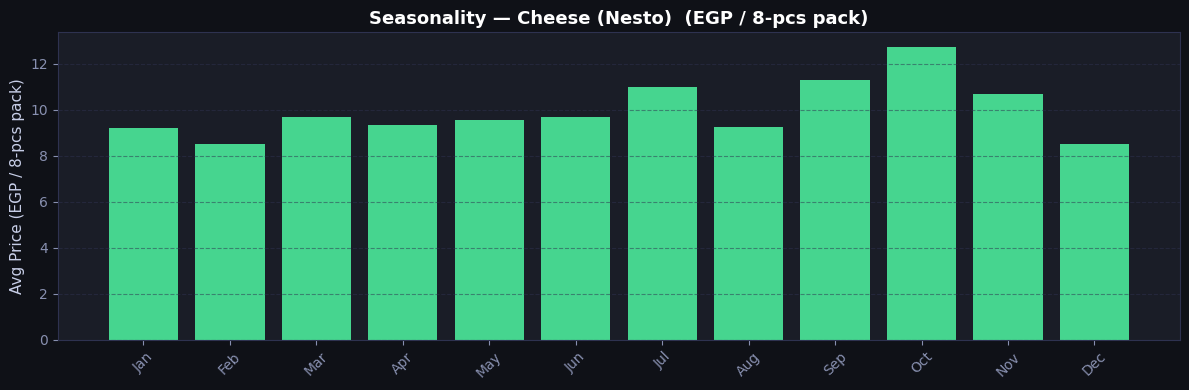

In [127]:
#  Cheese seasonality (EGP / pack) 
if len(df_pack) > 0:
    sc = df_pack.groupby(['Month','Month_Name'])['Price'].mean().reset_index()
    sc['Month_Name'] = pd.Categorical(sc['Month_Name'], categories=MONTH_ORDER, ordered=True)
    sc = sc.sort_values('Month_Name')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(sc['Month_Name'].astype(str), sc['Price'],
           color=P[2], alpha=0.85, edgecolor='none')
    ax.set_title('Seasonality — Cheese (Nesto)  (EGP / 8-pcs pack)', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Avg Price (EGP / 8-pcs pack)')
    ax.grid(True, axis='y')
    plt.tight_layout()
    savefig('20_seasonality_cheese')
    plt.show()

## 11. Correlation Matrix  (KG only)

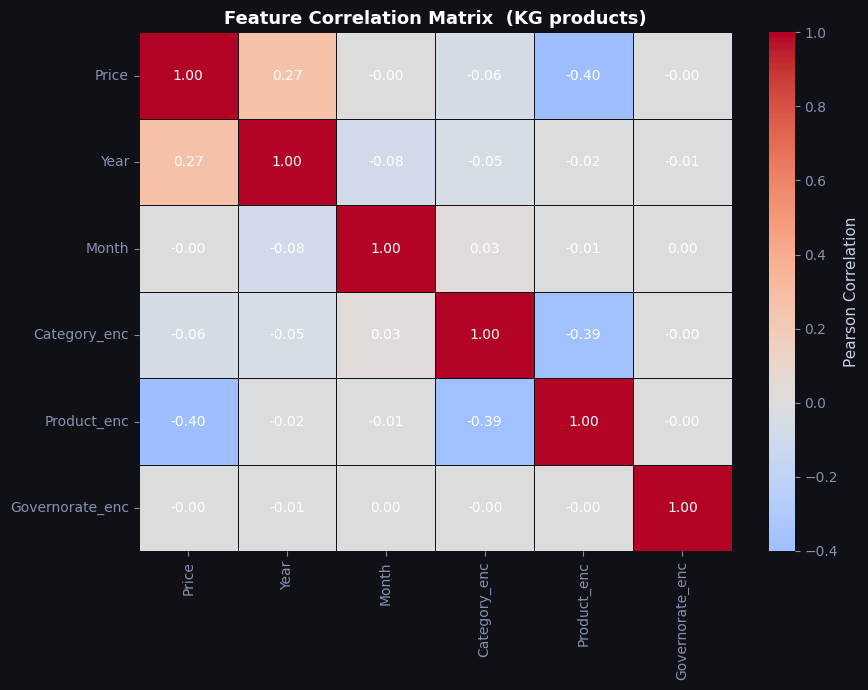

In [128]:
df_enc = df_kg.copy()
df_enc['Category_enc']    = df_enc['Category'].astype('category').cat.codes
df_enc['Product_enc']     = df_enc['Product'].astype('category').cat.codes
df_enc['Governorate_enc'] = df_enc['Governorate'].astype('category').cat.codes

corr = df_enc[['Price','Year','Month',
               'Category_enc','Product_enc','Governorate_enc']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f',
            linewidths=0.5, linecolor=BG,
            annot_kws={'size': 10, 'color': 'white'},
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix  (KG products)', fontweight='bold')
plt.tight_layout()
savefig('21_correlation_matrix')
plt.show()